Введите уровень завершенности проекта(0-100):  56.5
Введите уровень риска(0-100):  35.4


Степень принадлежности для уровня завершенности: 0.90
Степень принадлежности для уровня риска: 0.73


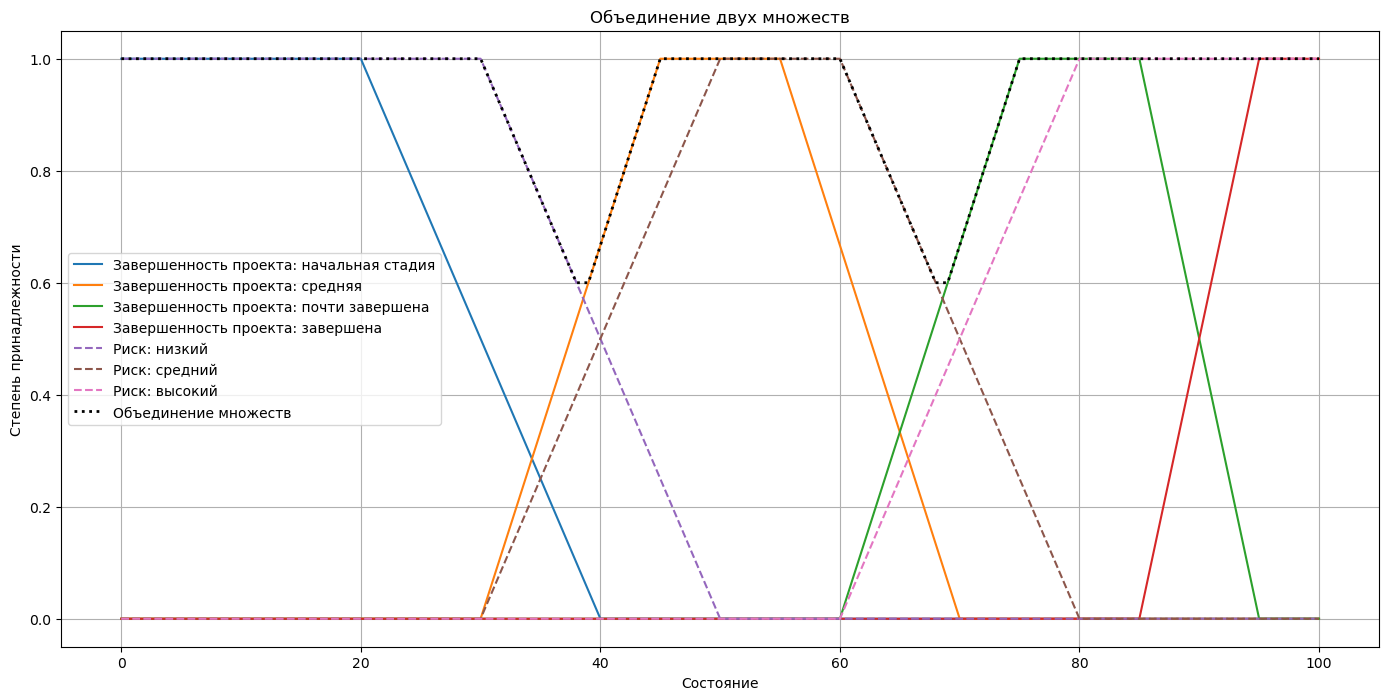

In [8]:
'''

На языке Python разработайте скрипт, позволяющий задать нечеткое множество с трапециевидной функцией принадлежности и отобразить его параметры,
а также степень принадлежности вводимого пользователем объекта.


12. Менеджмент проектов
Завершенность проекта: начальная стадия, средняя, почти завершена, завершена
Риски: низкие, средние, высокие


1. Дайте определение нечеткому множеству.
2. Какие способы задания функций принадлежности вы знаете?
3. Какую операцию вы реализовали в своей лабораторной работе?
'''

import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

x = np.arange(0, 101, 1)

complete_start = fuzz.trapmf(x, [0, 0, 20, 40])
complete_avr = fuzz.trapmf(x, [30, 45, 55, 70])
complete_alend = fuzz.trapmf(x, [60, 75, 85, 95])
complete_end = fuzz.trapmf(x, [85, 95, 100, 100])

risks_low = fuzz.trapmf(x, [0, 0, 30, 50])
risks_avr = fuzz.trapmf(x, [30, 50, 60, 80])
risks_high = fuzz.trapmf(x, [60, 80, 100, 100])

complete_val = float(input("Введите уровень завершенности проекта(0-100): "))
risks_val = float(input("Введите уровень риска(0-100): "))

complete_membership = max(
    fuzz.interp_membership(x, complete_start, complete_val),
    fuzz.interp_membership(x, complete_avr, complete_val),
    fuzz.interp_membership(x, complete_alend, complete_val),
    fuzz.interp_membership(x, complete_end, complete_val),
)


risks_membership = max(
    fuzz.interp_membership(x, risks_low, risks_val),
    fuzz.interp_membership(x, risks_avr, risks_val),
    fuzz.interp_membership(x, risks_high, risks_val),
)

union_complete = np.fmax(complete_start, complete_avr)
union_complete = np.fmax(union_complete, complete_alend)
union_complete = np.fmax(union_complete, complete_end)

union_risks = np.fmax(risks_low, risks_avr)
union_risks = np.fmax(union_risks, risks_high)

union_set = np.fmax(union_complete, union_risks)

print(f"Степень принадлежности для уровня завершенности: {complete_membership:.2f}")
print(f"Степень принадлежности для уровня риска: {risks_membership:.2f}")

plt.figure(figsize=(17, 8))

plt.plot(x, complete_start, label="Завершенность проекта: начальная стадия")
plt.plot(x, complete_avr, label="Завершенность проекта: средняя")
plt.plot(x, complete_alend, label="Завершенность проекта: почти завершена")
plt.plot(x, complete_end, label="Завершенность проекта: завершена")

plt.plot(x, risks_low, "--", label="Риск: низкий")
plt.plot(x, risks_avr, "--", label="Риск: средний")
plt.plot(x, risks_high, "--", label="Риск: высокий")

plt.plot(x, union_set, ":", label="Объединение множеств", linewidth=2, color="black")

plt.title("Объединение двух множеств")
plt.xlabel("Состояние")
plt.ylabel("Степень принадлежности")
plt.legend()
plt.grid()
plt.show()